# E23CSEU0868
# B-29
# Lab-5

In [49]:
!pip install -q kagglehub[pandas-datasets]

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub
from kagglehub import KaggleDatasetAdapter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

# DATA ACQUISITION AND EXPLORATION

In [51]:
file_path = "dermatology_database_1.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "olcaybolat1/dermatology-dataset-classification",
    file_path
)

print("First 5 records:")
display(df.head())

Using Colab cache for faster access to the 'dermatology-dataset-classification' dataset.
First 5 records:


,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_granular_layer,vacuolisation_damage_basal_layer,spongiosis,saw_tooth_appearance_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_mononuclear_infiltrate,band_like_infiltrate,age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45,3


In [52]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

Dataset shape: (366, 35)

Column names:
['erythema', 'scaling', 'definite_borders', 'itching', 'koebner_phenomenon', 'polygonal_papules', 'follicular_papules', 'oral_mucosal_involvement', 'knee_and_elbow_involvement', 'scalp_involvement', 'family_history', 'melanin_incontinence', 'eosinophils_infiltrate', 'PNL_infiltrate', 'fibrosis_papillary_dermis', 'exocytosis', 'acanthosis', 'hyperkeratosis', 'parakeratosis', 'clubbing_rete_ridges', 'elongation_rete_ridges', 'thinning_suprapapillary_epidermis', 'spongiform_pustule', 'munro_microabcess', 'focal_hypergranulosis', 'disappearance_granular_layer', 'vacuolisation_damage_basal_layer', 'spongiosis', 'saw_tooth_appearance_retes', 'follicular_horn_plug', 'perifollicular_parakeratosis', 'inflammatory_mononuclear_infiltrate', 'band_like_infiltrate', 'age', 'class']


In [53]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 35 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   erythema                             366 non-null    int64 
 1   scaling                              366 non-null    int64 
 2   definite_borders                     366 non-null    int64 
 3   itching                              366 non-null    int64 
 4   koebner_phenomenon                   366 non-null    int64 
 5   polygonal_papules                    366 non-null    int64 
 6   follicular_papules                   366 non-null    int64 
 7   oral_mucosal_involvement             366 non-null    int64 
 8   knee_and_elbow_involvement           366 non-null    int64 
 9   scalp_involvement                    366 non-null    int64 
 10  family_history                       366 non-null    int64 
 11  melanin_incontinence    

In [54]:
print("First 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

First 5 rows:


,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_granular_layer,vacuolisation_damage_basal_layer,spongiosis,saw_tooth_appearance_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_mononuclear_infiltrate,band_like_infiltrate,age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45,3



Last 5 rows:


,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_granular_layer,vacuolisation_damage_basal_layer,spongiosis,saw_tooth_appearance_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_mononuclear_infiltrate,band_like_infiltrate,age,class
361,2,1,1,0,1,0,0,0,0,0,...,0,0,1,0,0,0,2,0,25,4
362,3,2,1,0,1,0,0,0,0,0,...,1,0,1,0,0,0,2,0,36,4
363,3,2,2,2,3,2,0,2,0,0,...,0,3,0,3,0,0,2,3,28,3
364,2,1,3,1,2,3,0,2,0,0,...,0,2,0,1,0,0,2,3,50,3
365,3,2,2,0,0,0,0,0,3,3,...,2,0,0,0,0,0,3,0,35,1


In [55]:
print("Unique target classes:")
print(sorted(df["class"].unique()))

print("\nClass counts:")
print(df["class"].value_counts().sort_index())

Unique target classes:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]

Class counts:
class
1    112
2     61
3     72
4     49
5     52
6     20
Name: count, dtype: int64


In [57]:
class_names = {
    1: "Psoriasis",
    2: "Seborrheic Dermatitis",
    3: "Lichen Planus",
    4: "Pityriasis Rosea",
    5: "Chronic Dermatitis",
    6: "Pityriasis Rubra Pilaris"
}

for number, disease in class_names.items():
    print(number, ":", disease)

1 : Psoriasis
2 : Seborrheic Dermatitis
3 : Lichen Planus
4 : Pityriasis Rosea
5 : Chronic Dermatitis
6 : Pityriasis Rubra Pilaris


In [58]:
print("Data types before cleaning:")
print(df.dtypes)

Data types before cleaning:
erythema                                int64
scaling                                 int64
definite_borders                        int64
itching                                 int64
koebner_phenomenon                      int64
polygonal_papules                       int64
follicular_papules                      int64
oral_mucosal_involvement                int64
knee_and_elbow_involvement              int64
scalp_involvement                       int64
family_history                          int64
melanin_incontinence                    int64
eosinophils_infiltrate                  int64
PNL_infiltrate                          int64
fibrosis_papillary_dermis               int64
exocytosis                              int64
acanthosis                              int64
hyperkeratosis                          int64
parakeratosis                           int64
clubbing_rete_ridges                    int64
elongation_rete_ridges                  int64
thinni

In [59]:
# Replace '?' with NaN
df = df.replace("?", np.nan)

print("Missing values in each column:")
display(df.isnull().sum().to_frame("Missing Values"))

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values in each column:


,Missing Values
erythema,0
scaling,0
definite_borders,0
itching,0
koebner_phenomenon,0
polygonal_papules,0
follicular_papules,0
oral_mucosal_involvement,0
knee_and_elbow_involvement,0
scalp_involvement,0



Total missing values: 8


In [60]:
for column in df.columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

print(df.dtypes)

erythema                                 int64
scaling                                  int64
definite_borders                         int64
itching                                  int64
koebner_phenomenon                       int64
polygonal_papules                        int64
follicular_papules                       int64
oral_mucosal_involvement                 int64
knee_and_elbow_involvement               int64
scalp_involvement                        int64
family_history                           int64
melanin_incontinence                     int64
eosinophils_infiltrate                   int64
PNL_infiltrate                           int64
fibrosis_papillary_dermis                int64
exocytosis                               int64
acanthosis                               int64
hyperkeratosis                           int64
parakeratosis                            int64
clubbing_rete_ridges                     int64
elongation_rete_ridges                   int64
thinning_supr

In [61]:
feature_columns = [column for column in df.columns if column != "class"]

for column in feature_columns:
    df[column] = df[column].fillna(df[column].median())

print("Total missing values after handling:",
      df.isnull().sum().sum())

Total missing values after handling: 0


In [62]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [63]:
summary_statistics = df[feature_columns].describe().T

summary_statistics["median"] = df[feature_columns].median()

summary_statistics = summary_statistics[
    [
        "count",
        "mean",
        "median",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max"
    ]
]

display(summary_statistics)

,count,mean,median,std,min,25%,50%,75%,max
erythema,366.0,2.068306,2.0,0.664753,0.0,2.0,2.0,2.0,3.0
scaling,366.0,1.795082,2.0,0.701527,0.0,1.0,2.0,2.0,3.0
definite_borders,366.0,1.549180,2.0,0.907525,0.0,1.0,2.0,2.0,3.0
itching,366.0,1.366120,1.0,1.138299,0.0,0.0,1.0,2.0,3.0
koebner_phenomenon,366.0,0.633880,0.0,0.908016,0.0,0.0,0.0,1.0,3.0
polygonal_papules,366.0,0.448087,0.0,0.957327,0.0,0.0,0.0,0.0,3.0
follicular_papules,366.0,0.166667,0.0,0.570588,0.0,0.0,0.0,0.0,3.0
oral_mucosal_involvement,366.0,0.377049,0.0,0.834147,0.0,0.0,0.0,0.0,3.0
knee_and_elbow_involvement,366.0,0.614754,0.0,0.982979,0.0,0.0,0.0,1.0,3.0
scalp_involvement,366.0,0.519126,0.0,0.905639,0.0,0.0,0.0,1.0,3.0


In [64]:
Q1 = df[feature_columns].quantile(0.25)
Q3 = df[feature_columns].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (
    (df[feature_columns] < lower_bound) |
    (df[feature_columns] > upper_bound)
)

outlier_counts = outlier_mask.sum().sort_values(ascending=False)

print("Outliers detected in each feature:")
display(outlier_counts.to_frame("Outlier Count"))

Outliers detected in each feature:


,Outlier Count
acanthosis,156
erythema,151
munro_microabcess,80
band_like_infiltrate,77
saw_tooth_appearance_retes,72
vacuolisation_damage_basal_layer,72
focal_hypergranulosis,71
spongiform_pustule,70
melanin_incontinence,70
polygonal_papules,69


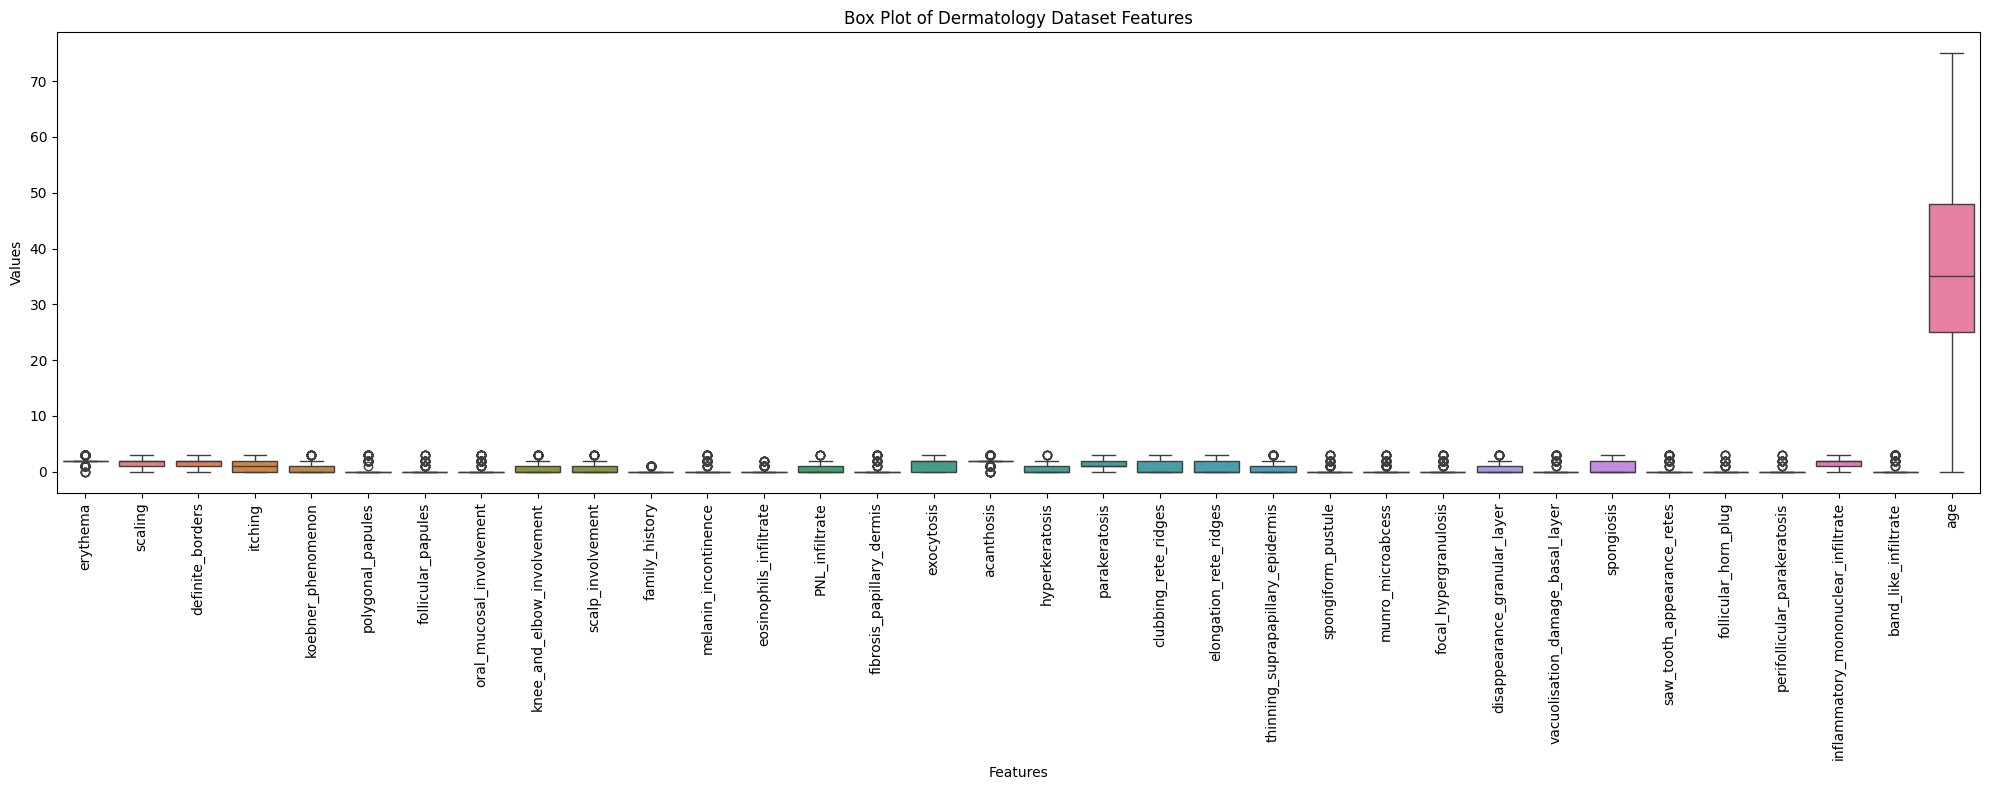

In [65]:
plt.figure(figsize=(20, 8))

sns.boxplot(data=df[feature_columns])

plt.title("Box Plot of Dermatology Dataset Features")
plt.xlabel("Features")
plt.ylabel("Values")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

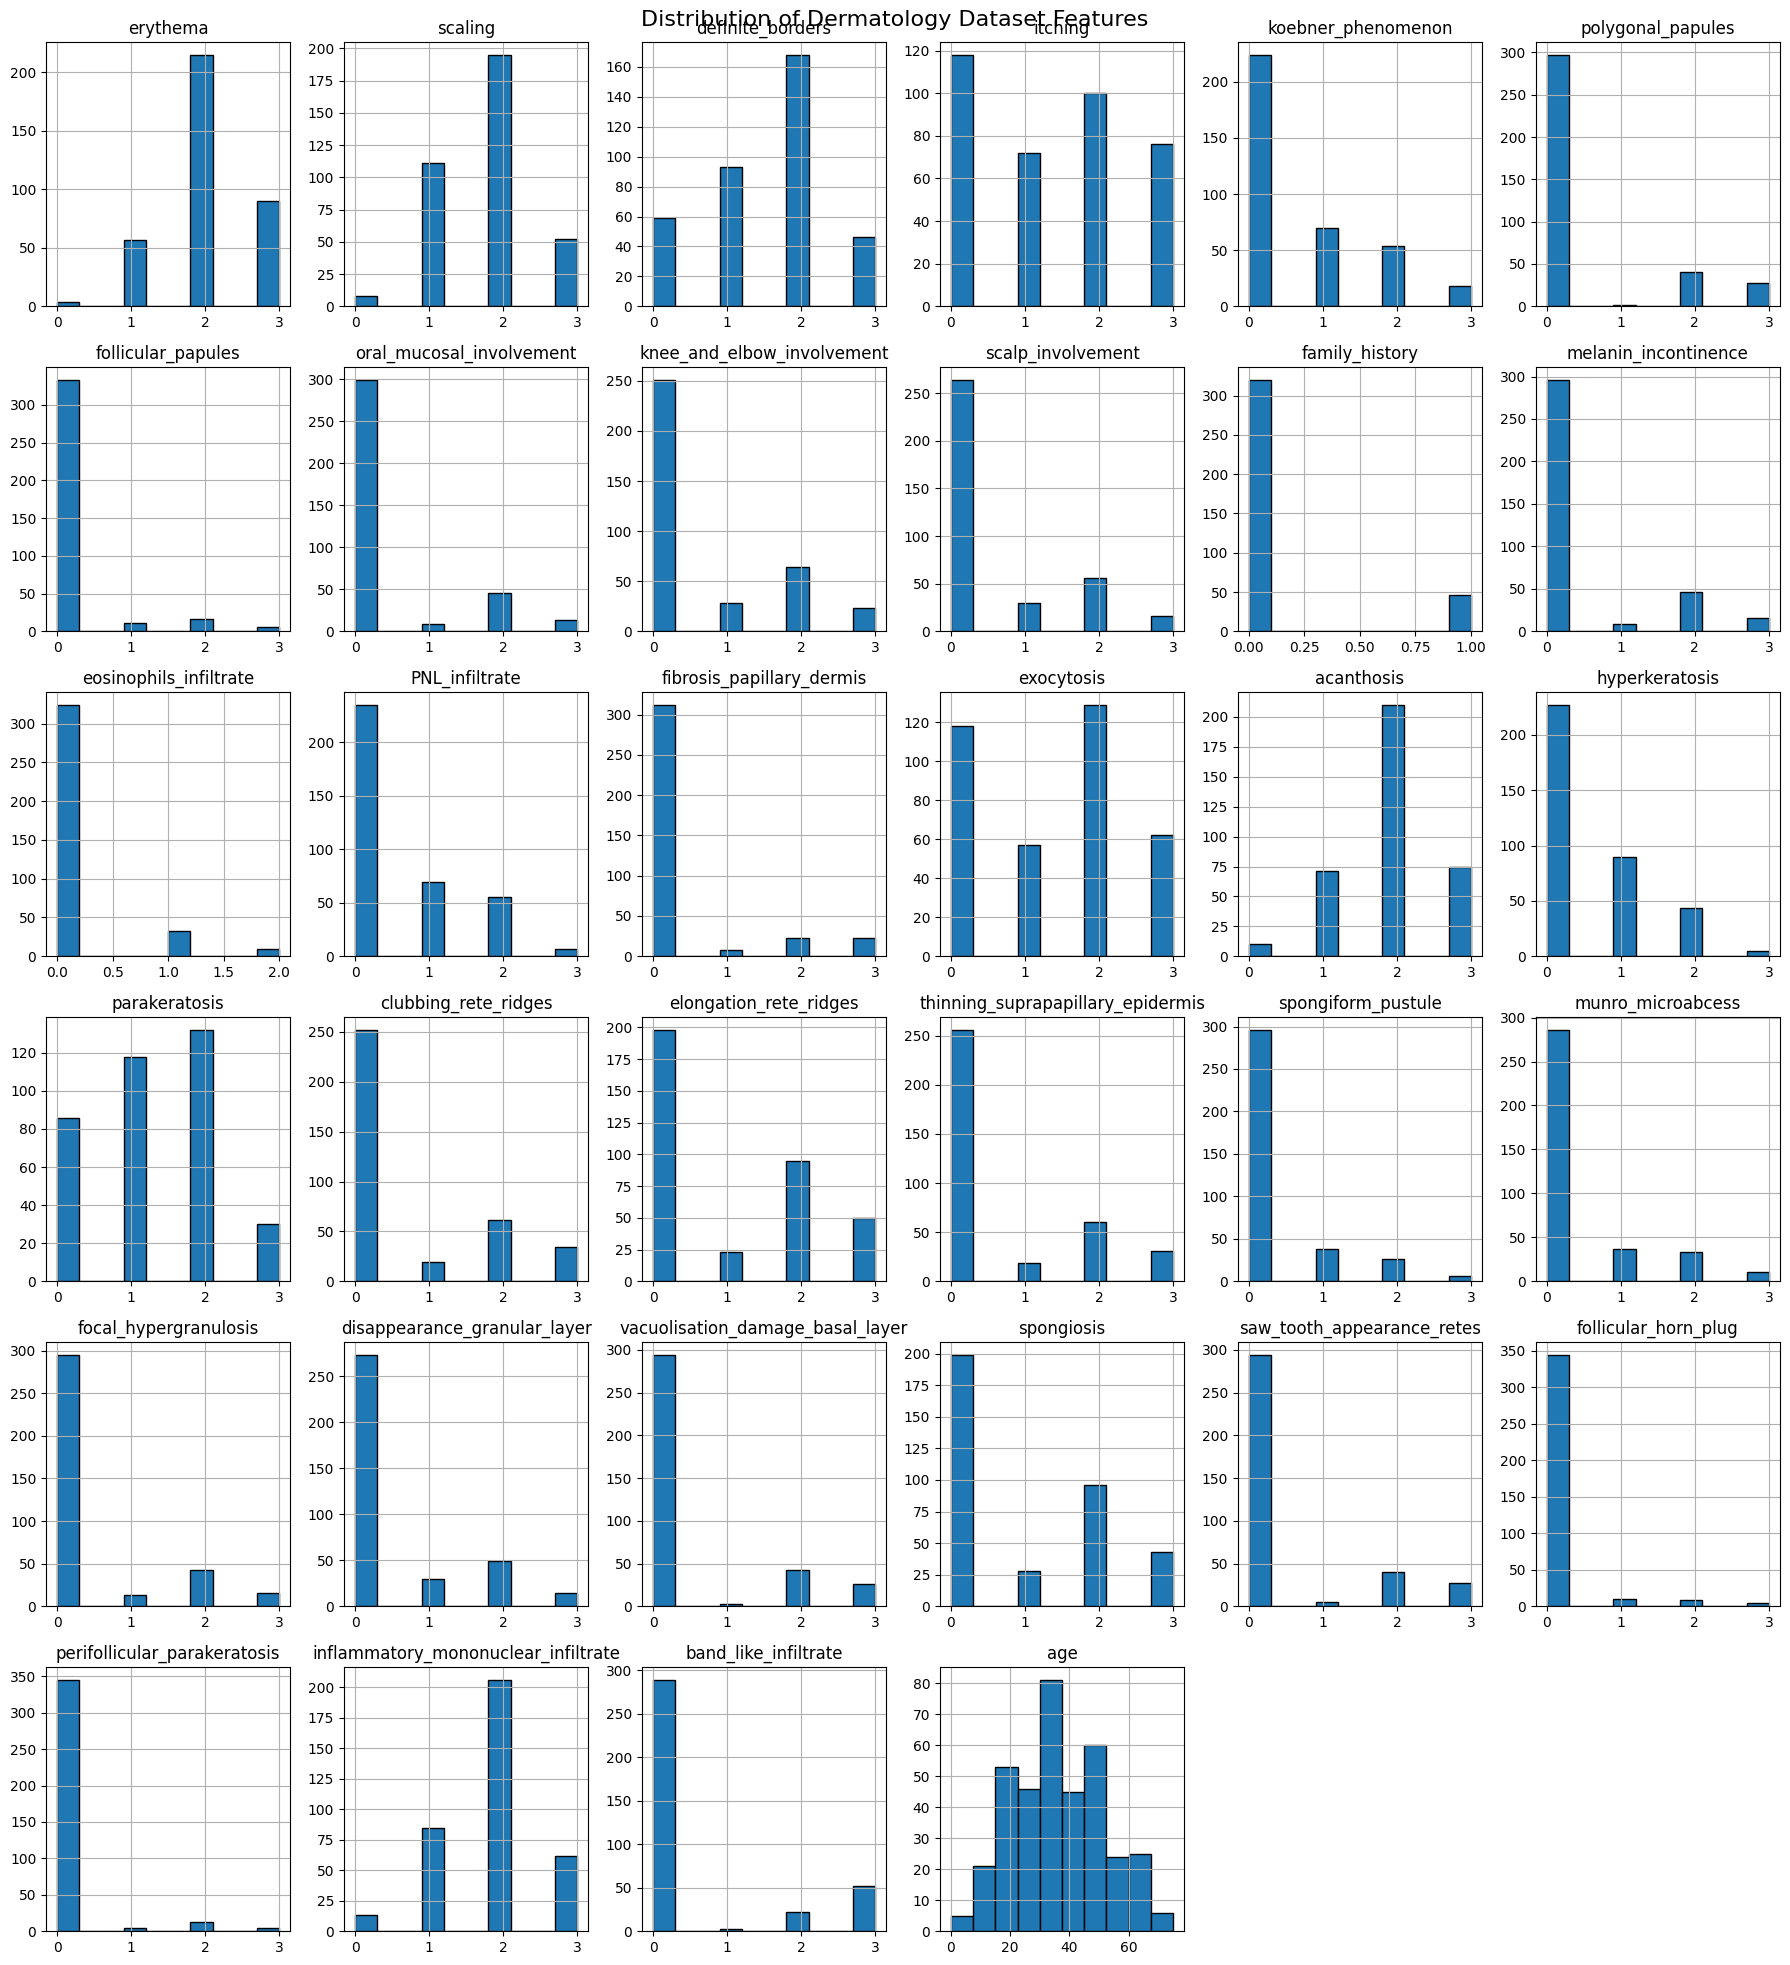

In [66]:
df[feature_columns].hist(
    figsize=(18, 20),
    bins=10,
    edgecolor="black"
)

plt.suptitle(
    "Distribution of Dermatology Dataset Features",
    fontsize=16
)

plt.tight_layout()
plt.show()

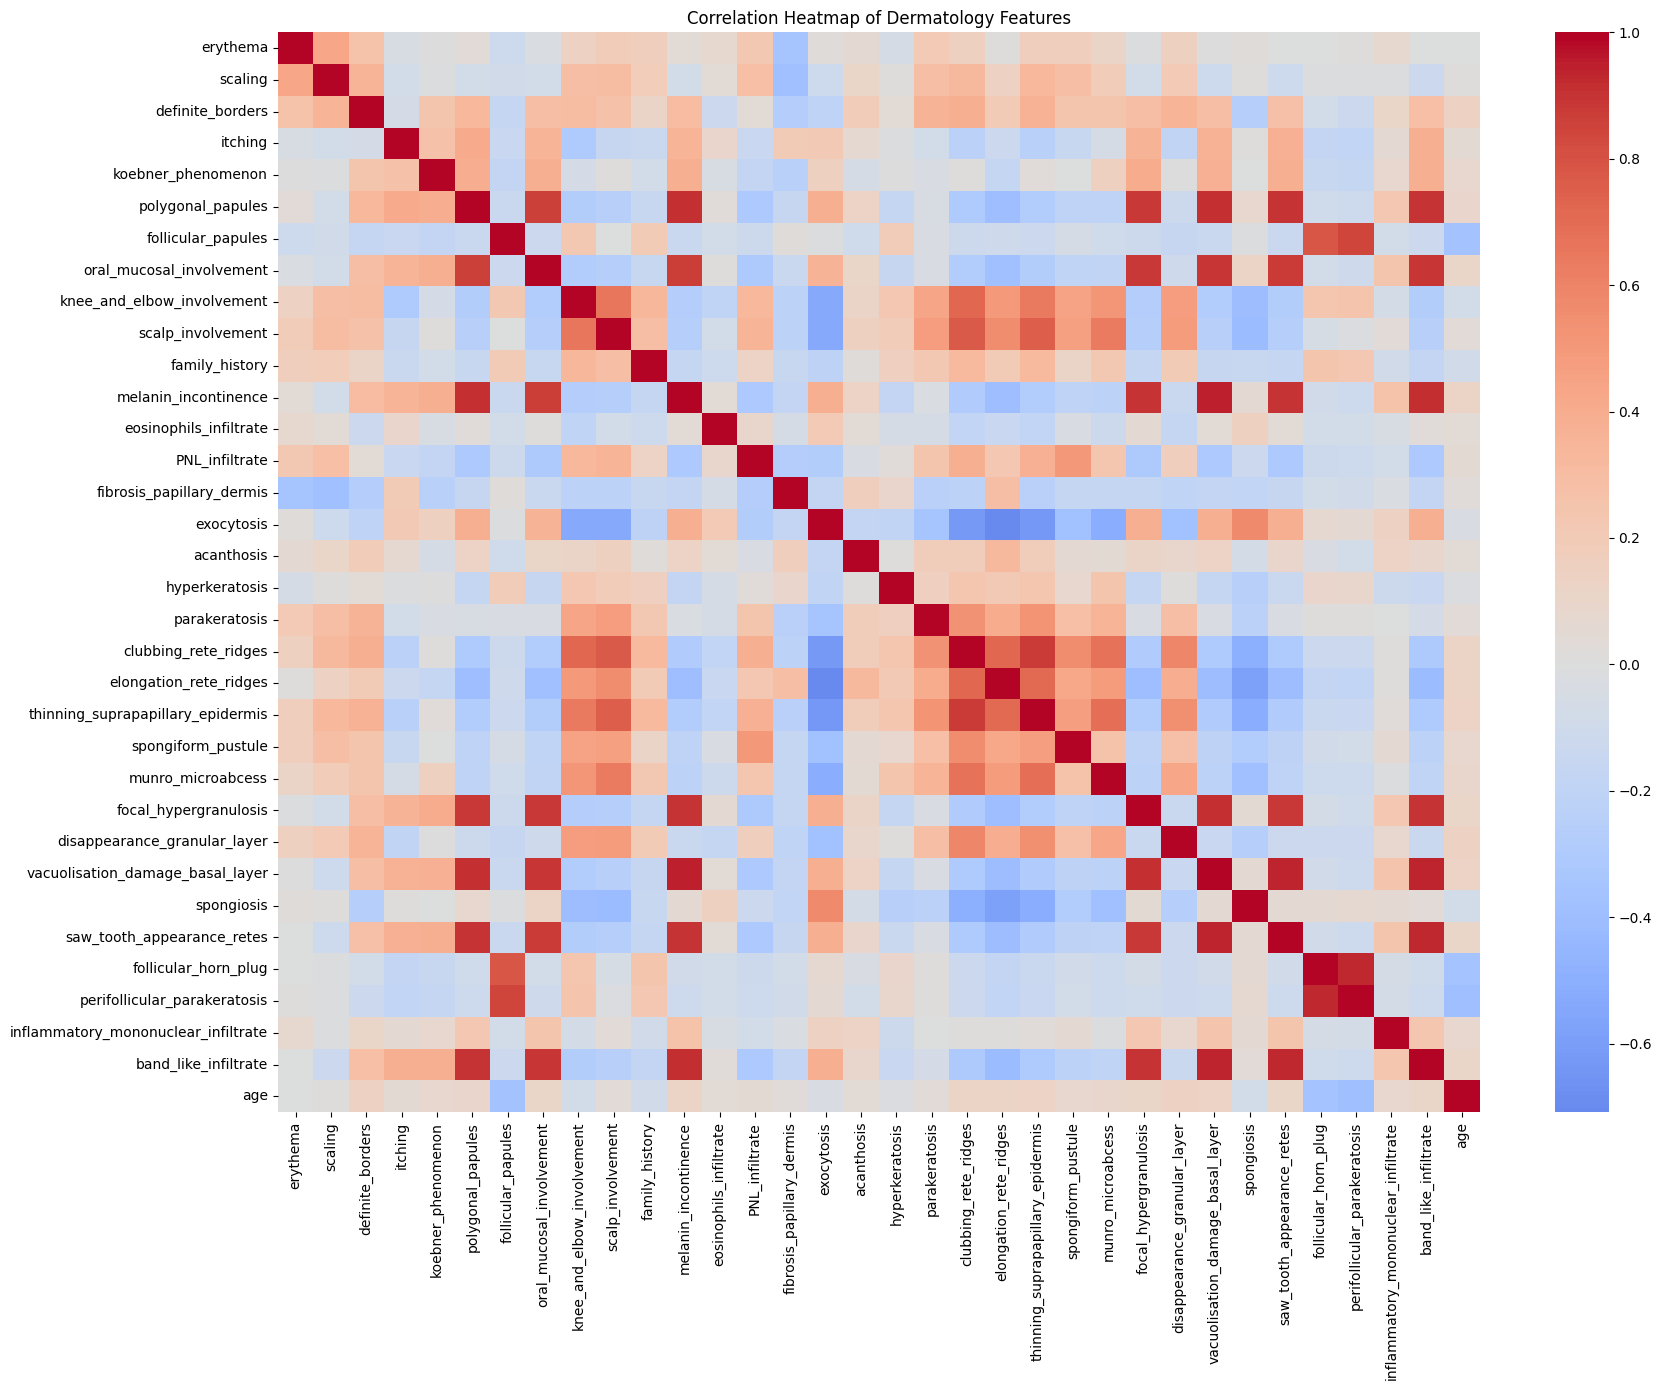

In [67]:
correlation_matrix = df[feature_columns].corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Dermatology Features")

plt.tight_layout()
plt.show()

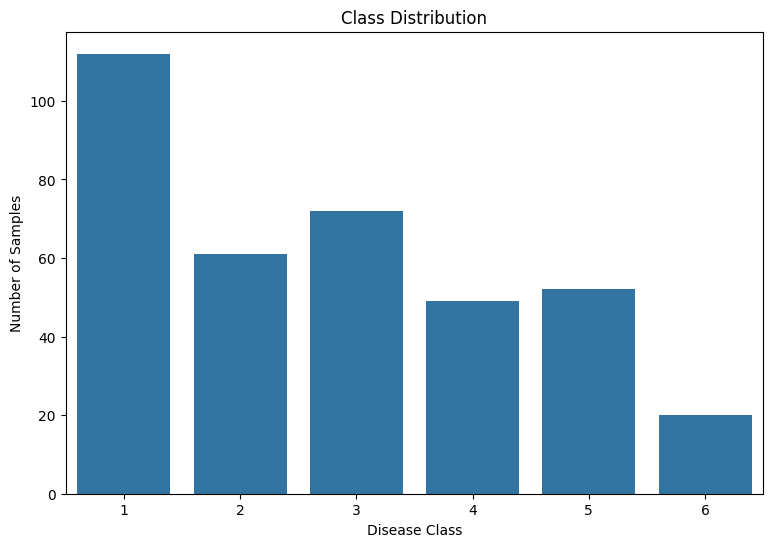

In [68]:
plt.figure(figsize=(9, 6))

sns.countplot(
    data=df,
    x="class",
    order=sorted(df["class"].unique())
)

plt.title("Class Distribution")
plt.xlabel("Disease Class")
plt.ylabel("Number of Samples")

plt.show()

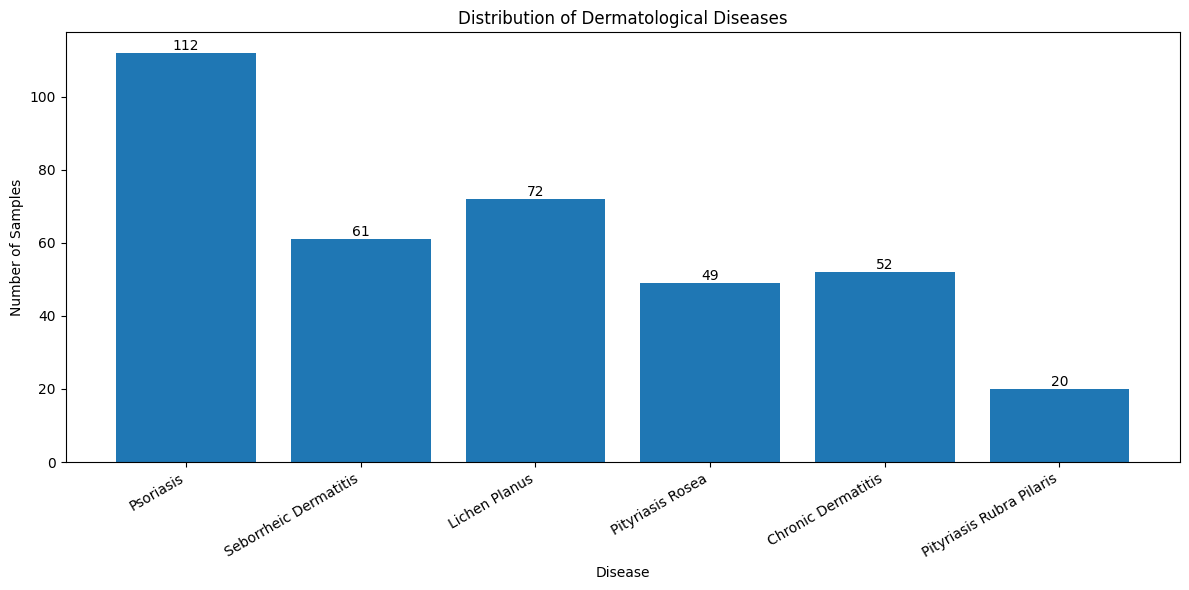

In [69]:
class_counts = df["class"].value_counts().sort_index()

labels = [class_names[i] for i in class_counts.index]

plt.figure(figsize=(12, 6))

bars = plt.bar(labels, class_counts.values)

plt.title("Distribution of Dermatological Diseases")
plt.xlabel("Disease")
plt.ylabel("Number of Samples")

plt.xticks(rotation=30, ha="right")

for bar, count in zip(bars, class_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(count),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [70]:
class_distribution = pd.DataFrame({
    "Class": class_counts.index,
    "Disease": [class_names[i] for i in class_counts.index],
    "Count": class_counts.values,
    "Percentage": (
        class_counts.values / len(df) * 100
    ).round(2)
})

display(class_distribution)

,Class,Disease,Count,Percentage
0,1,Psoriasis,112,30.60
1,2,Seborrheic Dermatitis,61,16.67
2,3,Lichen Planus,72,19.67
3,4,Pityriasis Rosea,49,13.39
4,5,Chronic Dermatitis,52,14.21
5,6,Pityriasis Rubra Pilaris,20,5.46


In [71]:
print("""
Class Imbalance Discussion:

The Dermatology dataset contains six different disease classes,
and the number of observations is not exactly equal across all
classes. Therefore, some degree of class imbalance is present.

Class imbalance can cause a machine learning model to perform
better on majority classes and worse on minority classes.

To reduce the effect of unequal class representation during
model training and evaluation, stratified sampling will be used
during the train-test split. Precision, recall, F1-score and
confusion matrices will also be considered along with accuracy.
""")


Class Imbalance Discussion:

The Dermatology dataset contains six different disease classes,
and the number of observations is not exactly equal across all
classes. Therefore, some degree of class imbalance is present.

Class imbalance can cause a machine learning model to perform
better on majority classes and worse on minority classes.

To reduce the effect of unequal class representation during
model training and evaluation, stratified sampling will be used
during the train-test split. Precision, recall, F1-score and
confusion matrices will also be considered along with accuracy.



# DATA PREPROCESSING

In [72]:
X = df.drop("class", axis=1)
y = df["class"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (366, 34)
Target shape: (366,)


In [73]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Original classes:")
print(label_encoder.classes_)

print("\nEncoded classes:")
print(np.unique(y_encoded))

Original classes:
[1 2 3 4 5 6]

Encoded classes:
[0 1 2 3 4 5]


In [74]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 292
Testing samples: 74


In [75]:
print("Training class distribution:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nTesting class distribution:")
print(pd.Series(y_test).value_counts().sort_index())

Training class distribution:
0    89
1    49
2    57
3    39
4    42
5    16
Name: count, dtype: int64

Testing class distribution:
0    23
1    12
2    15
3    10
4    10
5     4
Name: count, dtype: int64


In [76]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Training data shape: (292, 34)
Testing data shape: (74, 34)


# MODEL TRAINING AND BASIC EVALUATION

In [77]:
# Logistic Regression
lr_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)
lr_prob = lr_model.predict_proba(X_test_scaled)

In [78]:
# KNN
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)
knn_prob = knn_model.predict_proba(X_test_scaled)

In [79]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

rf_pred = rf_model.predict(X_test_scaled)
rf_prob = rf_model.predict_proba(X_test_scaled)

In [80]:
# SVM
svm_model = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

svm_pred = svm_model.predict(X_test_scaled)
svm_prob = svm_model.predict_proba(X_test_scaled)

In [81]:
# Decision Tree
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train_scaled, y_train)

dt_pred = dt_model.predict(X_test_scaled)
dt_prob = dt_model.predict_proba(X_test_scaled)

In [82]:
models = {
    "Logistic Regression": {
        "model": lr_model,
        "pred": lr_pred,
        "prob": lr_prob
    },
    "KNN": {
        "model": knn_model,
        "pred": knn_pred,
        "prob": knn_prob
    },
    "Random Forest": {
        "model": rf_model,
        "pred": rf_pred,
        "prob": rf_prob
    },
    "SVM": {
        "model": svm_model,
        "pred": svm_pred,
        "prob": svm_prob
    },
    "Decision Tree": {
        "model": dt_model,
        "pred": dt_pred,
        "prob": dt_prob
    }
}

In [83]:
results = []

for name, data in models.items():

    predictions = data["pred"]

    accuracy = accuracy_score(y_test, predictions)

    precision = precision_score(
        y_test,
        predictions,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        average="macro",
        zero_division=0
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

results_df = pd.DataFrame(results)

display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.959459,0.961538,0.961111,0.957362
1,KNN,0.905405,0.907143,0.909420,0.903428
2,Random Forest,0.959459,0.954545,0.955556,0.954451
3,SVM,0.972973,0.972222,0.972222,0.969697
4,Decision Tree,0.959459,0.936364,0.961111,0.944710


In [84]:
disease_names = [
    "Psoriasis",
    "Seborrheic Dermatitis",
    "Lichen Planus",
    "Pityriasis Rosea",
    "Chronic Dermatitis",
    "Pityriasis Rubra Pilaris"
]

for name, data in models.items():

    print("=" * 80)
    print(name)
    print("=" * 80)

    print(
        classification_report(
            y_test,
            data["pred"],
            target_names=disease_names,
            zero_division=0
        )
    )

Logistic Regression
                          precision    recall  f1-score   support

               Psoriasis       1.00      1.00      1.00        23
   Seborrheic Dermatitis       1.00      0.83      0.91        12
           Lichen Planus       1.00      0.93      0.97        15
        Pityriasis Rosea       0.77      1.00      0.87        10
      Chronic Dermatitis       1.00      1.00      1.00        10
Pityriasis Rubra Pilaris       1.00      1.00      1.00         4

                accuracy                           0.96        74
               macro avg       0.96      0.96      0.96        74
            weighted avg       0.97      0.96      0.96        74

KNN
                          precision    recall  f1-score   support

               Psoriasis       1.00      0.96      0.98        23
   Seborrheic Dermatitis       0.80      0.67      0.73        12
           Lichen Planus       1.00      0.93      0.97        15
        Pityriasis Rosea       0.64      0.90   

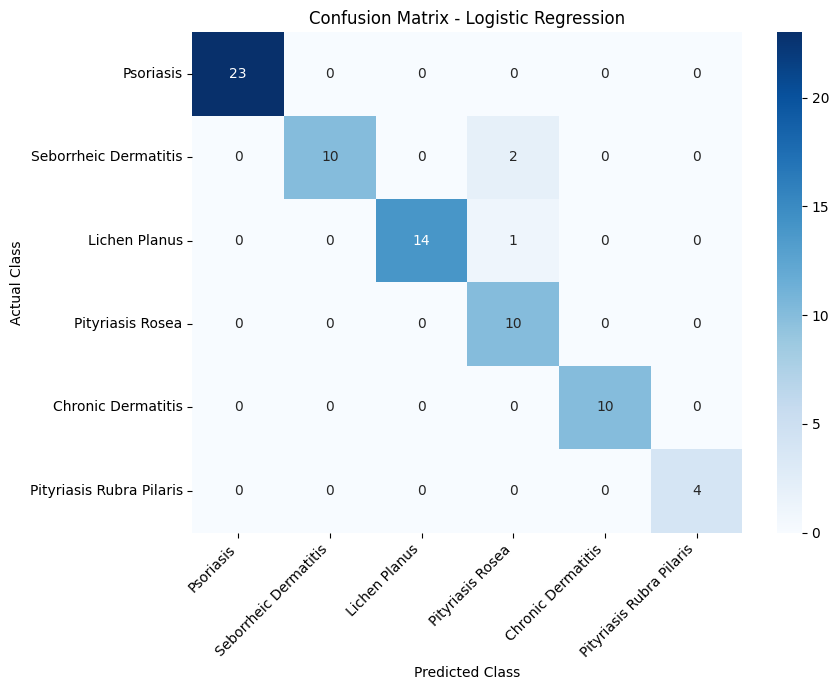

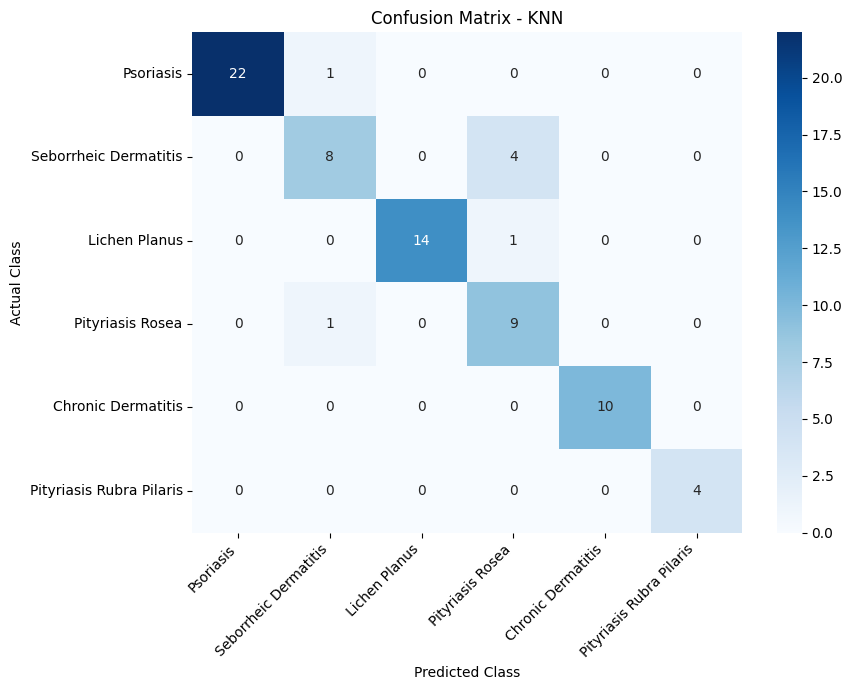

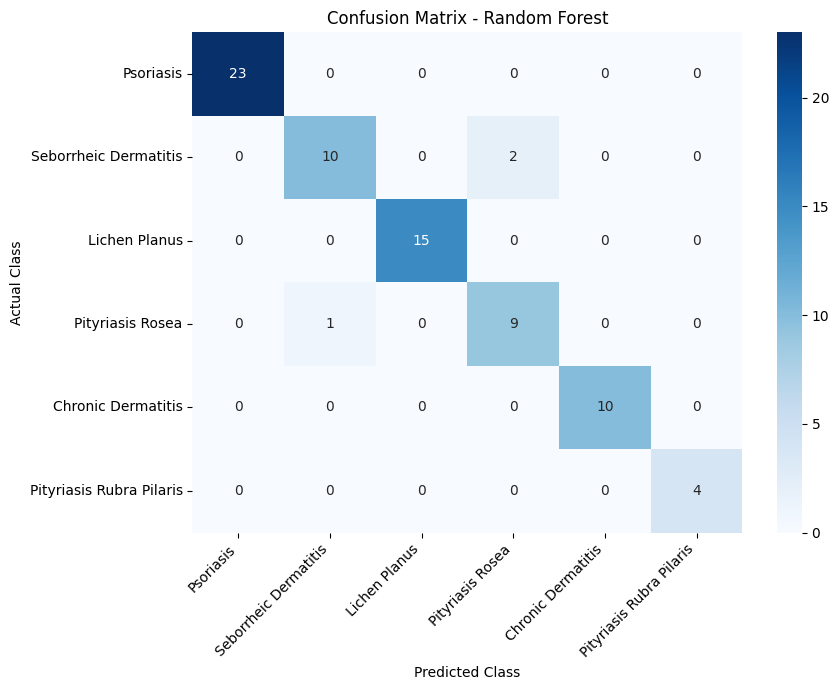

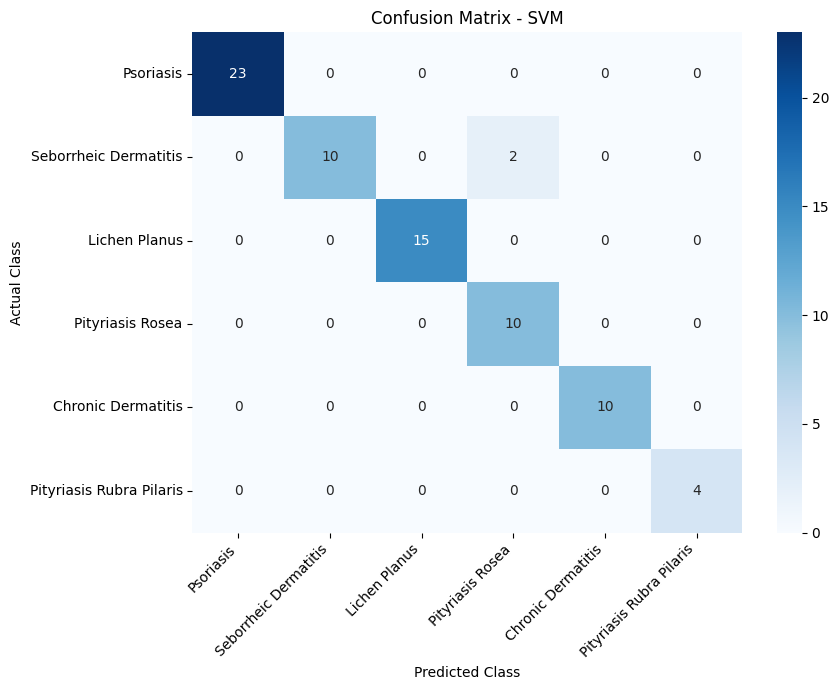

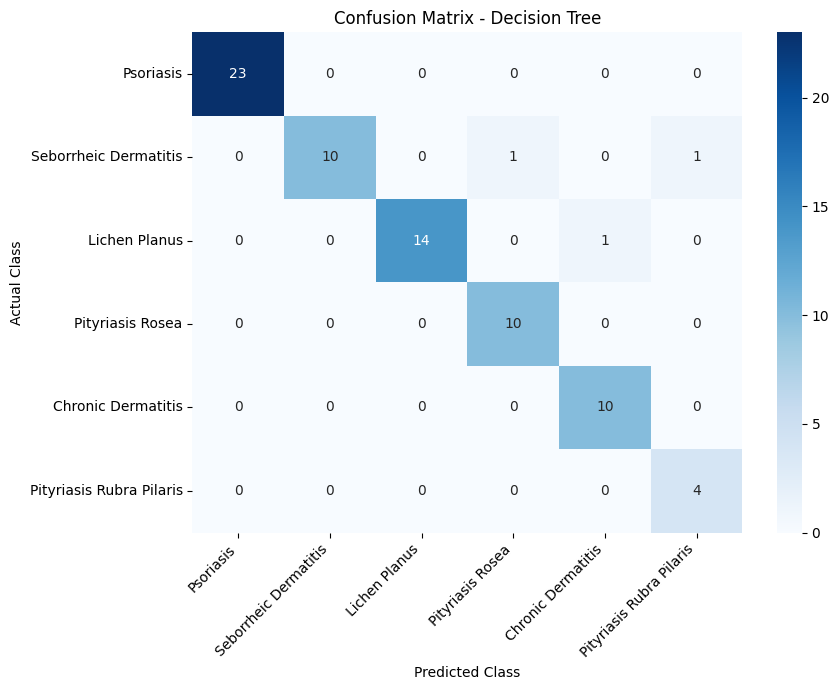

In [85]:
for name, data in models.items():

    cm = confusion_matrix(
        y_test,
        data["pred"]
    )

    plt.figure(figsize=(9, 7))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=disease_names,
        yticklabels=disease_names
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")

    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()

In [86]:
n_classes = 6

y_test_binarized = label_binarize(
    y_test,
    classes=np.arange(n_classes)
)

print("Binarized target shape:", y_test_binarized.shape)

Binarized target shape: (74, 6)


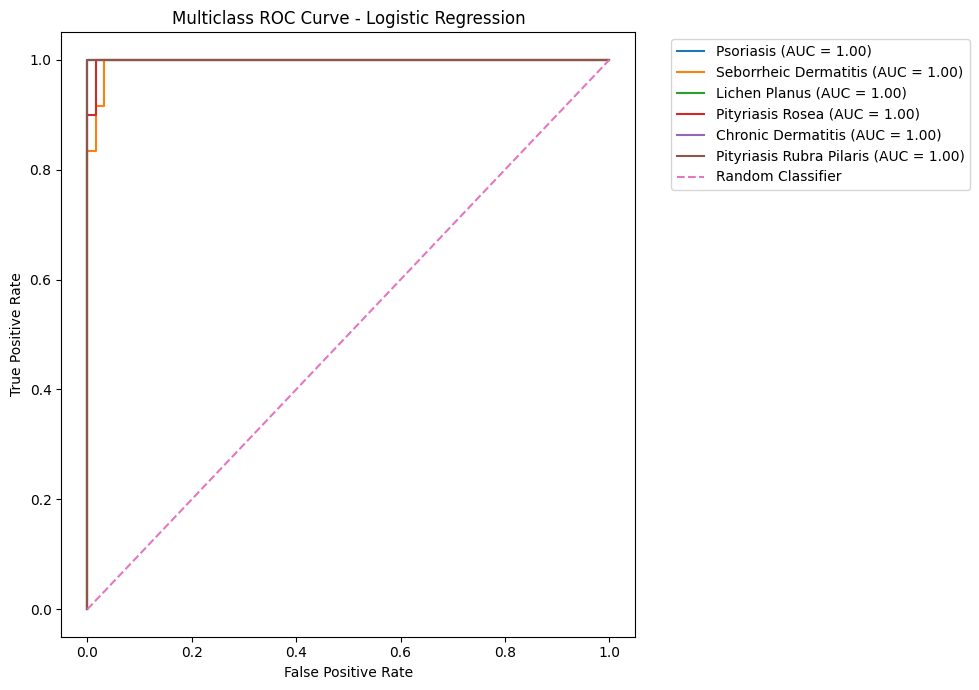

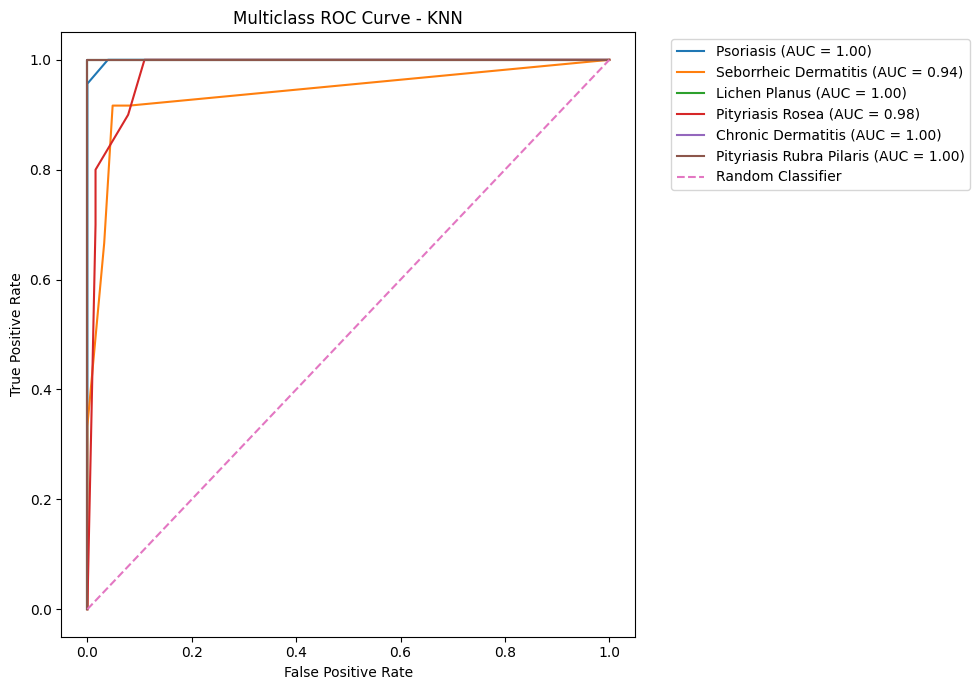

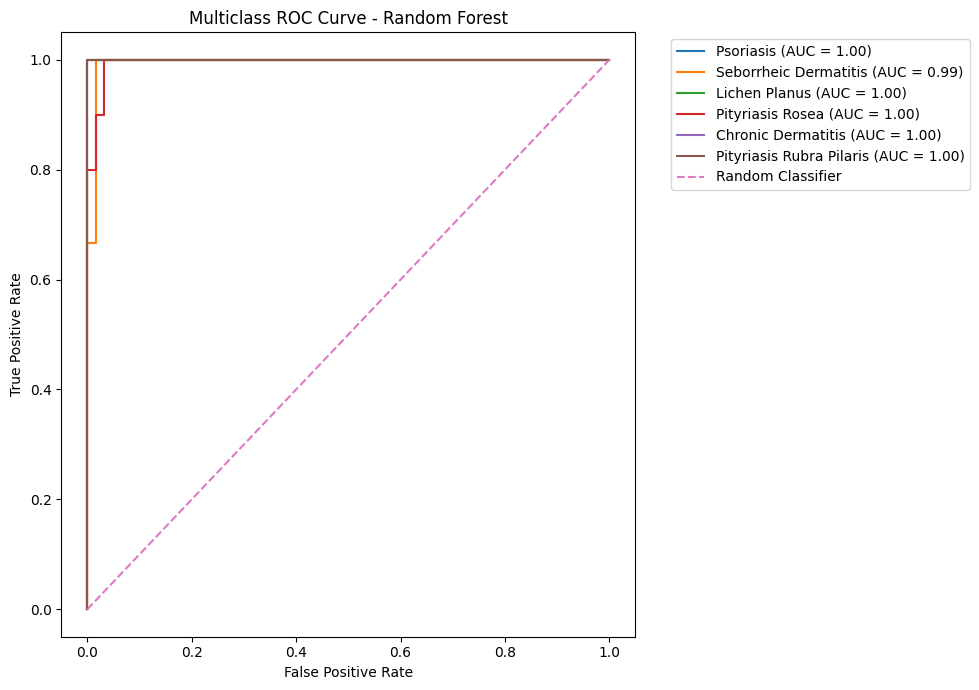

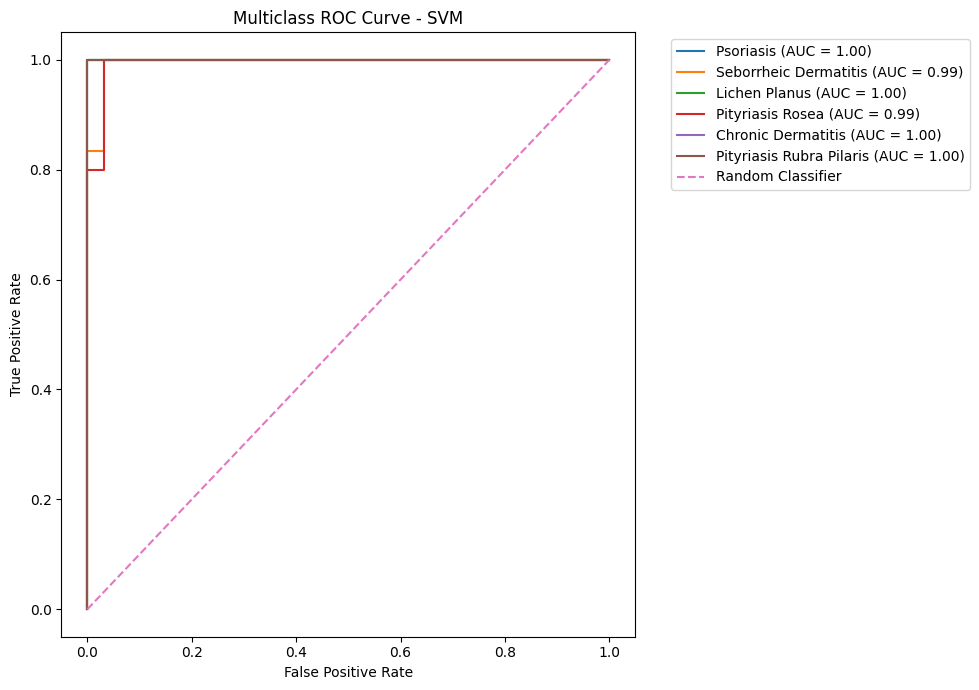

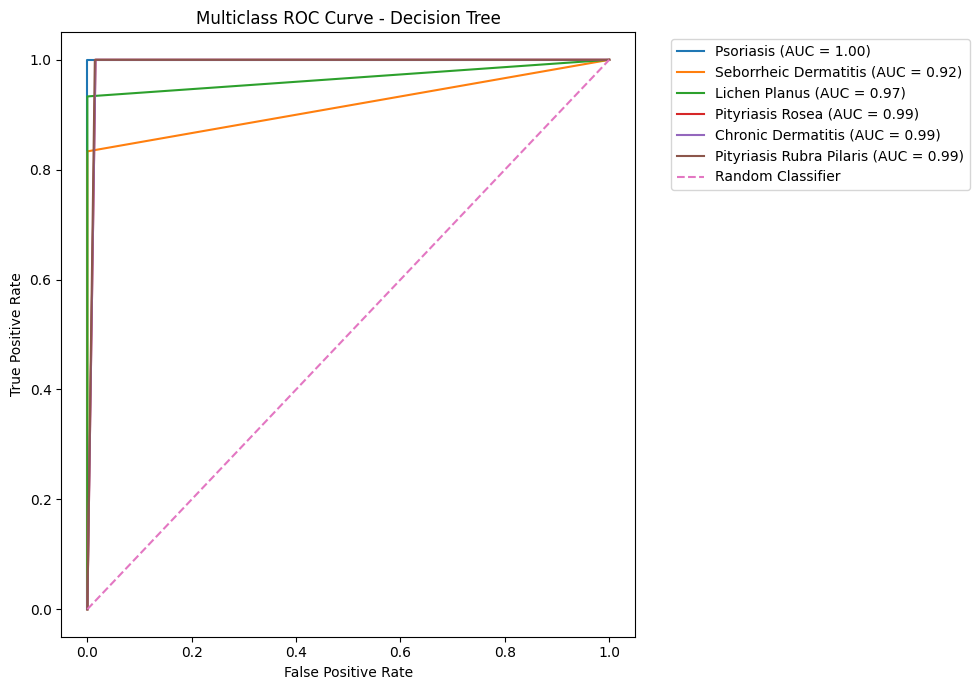

In [87]:
for name, data in models.items():

    probabilities = data["prob"]

    plt.figure(figsize=(10, 7))

    for i in range(n_classes):

        fpr, tpr, _ = roc_curve(
            y_test_binarized[:, i],
            probabilities[:, i]
        )

        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            label=f"{disease_names[i]} (AUC = {roc_auc:.2f})"
        )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Random Classifier"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title(f"Multiclass ROC Curve - {name}")

    plt.legend(
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()

In [88]:
auc_results = []

for name, data in models.items():

    macro_auc = roc_auc_score(
        y_test_binarized,
        data["prob"],
        multi_class="ovr",
        average="macro"
    )

    weighted_auc = roc_auc_score(
        y_test_binarized,
        data["prob"],
        multi_class="ovr",
        average="weighted"
    )

    auc_results.append({
        "Model": name,
        "Macro AUC": macro_auc,
        "Weighted AUC": weighted_auc
    })

auc_df = pd.DataFrame(auc_results)

display(auc_df)

,Model,Macro AUC,Weighted AUC
0,Logistic Regression,0.999068,0.999135
1,KNN,0.986262,0.987076
2,Random Forest,0.998323,0.998495
3,SVM,0.998062,0.998284
4,Decision Tree,0.976761,0.977232


In [89]:
final_results = results_df.merge(
    auc_df,
    on="Model"
)

display(final_results)

,Model,Accuracy,Precision,Recall,F1-Score,Macro AUC,Weighted AUC
0,Logistic Regression,0.959459,0.961538,0.961111,0.957362,0.999068,0.999135
1,KNN,0.905405,0.907143,0.909420,0.903428,0.986262,0.987076
2,Random Forest,0.959459,0.954545,0.955556,0.954451,0.998323,0.998495
3,SVM,0.972973,0.972222,0.972222,0.969697,0.998062,0.998284
4,Decision Tree,0.959459,0.936364,0.961111,0.944710,0.976761,0.977232


In [90]:
final_results_percentage = final_results.copy()

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "Macro AUC",
    "Weighted AUC"
]

for metric in metrics:
    final_results_percentage[metric] = (
        final_results_percentage[metric] * 100
    ).round(2)

display(final_results_percentage)

,Model,Accuracy,Precision,Recall,F1-Score,Macro AUC,Weighted AUC
0,Logistic Regression,95.95,96.15,96.11,95.74,99.91,99.91
1,KNN,90.54,90.71,90.94,90.34,98.63,98.71
2,Random Forest,95.95,95.45,95.56,95.45,99.83,99.85
3,SVM,97.30,97.22,97.22,96.97,99.81,99.83
4,Decision Tree,95.95,93.64,96.11,94.47,97.68,97.72


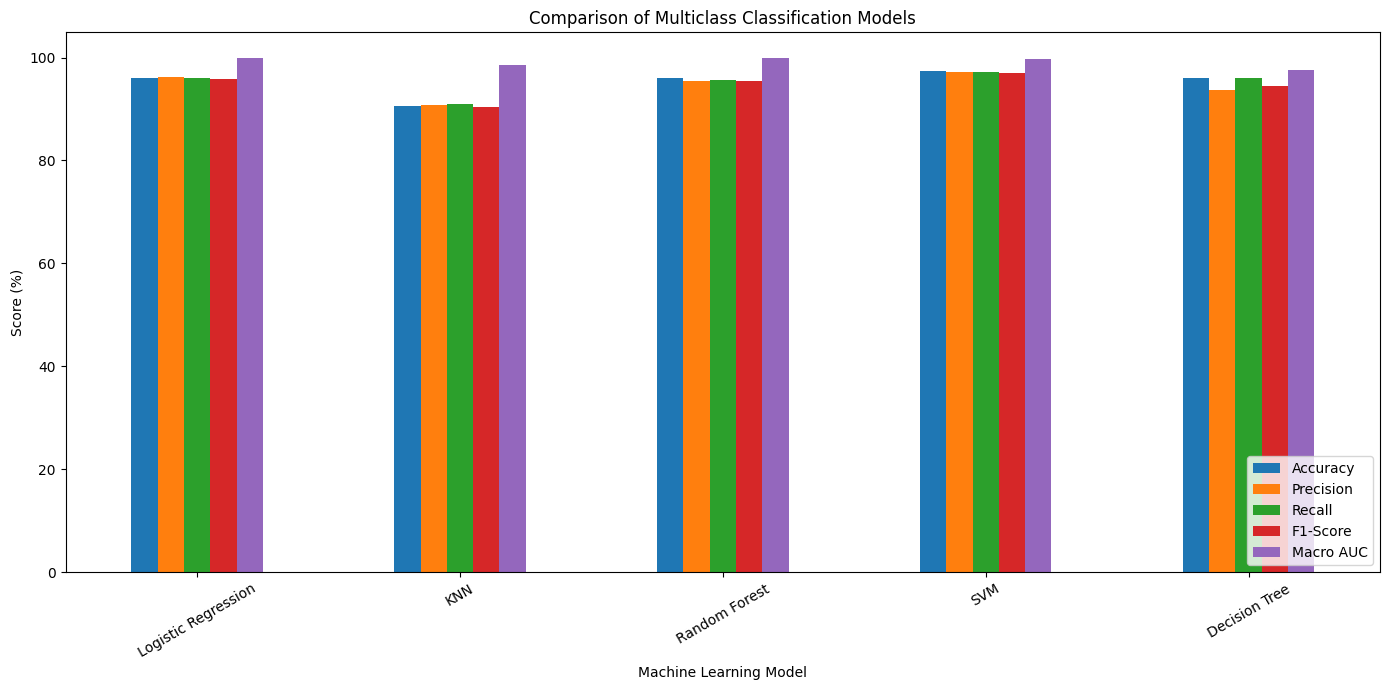

In [91]:
plot_data = final_results_percentage.set_index("Model")

plot_data[
    ["Accuracy", "Precision", "Recall", "F1-Score", "Macro AUC"]
].plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Comparison of Multiclass Classification Models")
plt.xlabel("Machine Learning Model")
plt.ylabel("Score (%)")

plt.xticks(rotation=30)
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [92]:
best_accuracy_model = final_results.loc[
    final_results["Accuracy"].idxmax(),
    "Model"
]

best_f1_model = final_results.loc[
    final_results["F1-Score"].idxmax(),
    "Model"
]

best_auc_model = final_results.loc[
    final_results["Macro AUC"].idxmax(),
    "Model"
]

print("Model with highest Accuracy:", best_accuracy_model)
print("Model with highest Macro F1-Score:", best_f1_model)
print("Model with highest Macro AUC:", best_auc_model)

Model with highest Accuracy: SVM
Model with highest Macro F1-Score: SVM
Model with highest Macro AUC: Logistic Regression
